In [ ]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from analysis.utils import load_sweep_metadata, load_data, compute_success

In [ ]:
df_metadata_probing = load_sweep_metadata([
    "logs/25-12-04-latent_intervention_control_sweep",
])

df_metadata_spsa = load_sweep_metadata([
    "logs/25-12-03-spsa-position",
])
df_metadata_spsa = df_metadata_spsa[(df_metadata_spsa['config_horizon'] == "1")
                                    & (df_metadata_spsa['config_eps'] == 1e-2)]

Dirs in logs/25-12-03-spsa-position: 100%|██████████| 1408/1408 [00:01<00:00, 1059.59it/s]

Found 1408 configurations


In [12]:
df_metadata_probing = df_metadata_probing[
    df_metadata_probing['config_lasso_alpha'].isin([0.0, np.nan])]
df_metadata = pd.concat([df_metadata_spsa, df_metadata_probing])
df_metadata['config_direction_str'] = df_metadata['config_direction_str'].where(
    pd.notnull(df_metadata['config_direction_str']),
    np.where(df_metadata.get('config_random', False), 'random', 'spsa'))

df_metadata = df_metadata[~df_metadata['config_magnitude'].isin([-10., 10.])]

# 8 seeds, 11 alphas (magnitude of directional addition)
df_metadata['config_direction_str'].value_counts()

config_direction_str
spsa                                    72
random                                  72
lr_w_global_position                    72
backprop_gradient_nonlinear_action      72
backprop_gradient_linear_position       72
w_action_lasso                          72
backprop_gradient_nonlinear_position    72
Name: count, dtype: int64

In [13]:
df = load_data(df_metadata)

Found 504 configurations


100%|██████████| 504/504 [00:01<00:00, 306.76it/s]


In [14]:
df = compute_success(df, starting_step=300, consecutive_steps=200)

In [15]:
dim_names = {
    0: 'Cart Position',
    1: 'cos(Pole Angle)',
    2: 'sin(Pole Angle)',
    3: 'Cart Velocity',
    4: 'Pole Angular Velocity',
}

In [16]:
df['config_hinge_1_value_degrees'] = np.degrees(df['config_hinge_1_value'])
df['hinge_str'] = df['config_hinge_1_value_degrees'].round(0).astype(str)

for dim in range(5):
    df[f'average_dim_{dim}'] = df['observations'].apply(
        lambda x: np.mean(np.array(x)[:, dim]))

df['total_position_change'] = df['observations'].apply(
    lambda x: np.array(x)[-1, 0] - np.array(x)[0, 0])

df['cumulative_abs_position_change'] = df['observations'].apply(
    lambda x: np.sum(np.abs(np.diff(np.array(x)[:, 0]))))

df['cumulative_position_change'] = df['observations'].apply(
    lambda x: np.sum(np.diff(np.array(x)[:, 0])))

In [17]:
grouped['config_magnitude'].value_counts()

config_magnitude
-10.0    8
-7.5     8
-5.0     8
-2.5     8
-1.0     8
 0.0     8
 1.0     8
 2.5     8
 5.0     8
 7.5     8
Name: count, dtype: int64

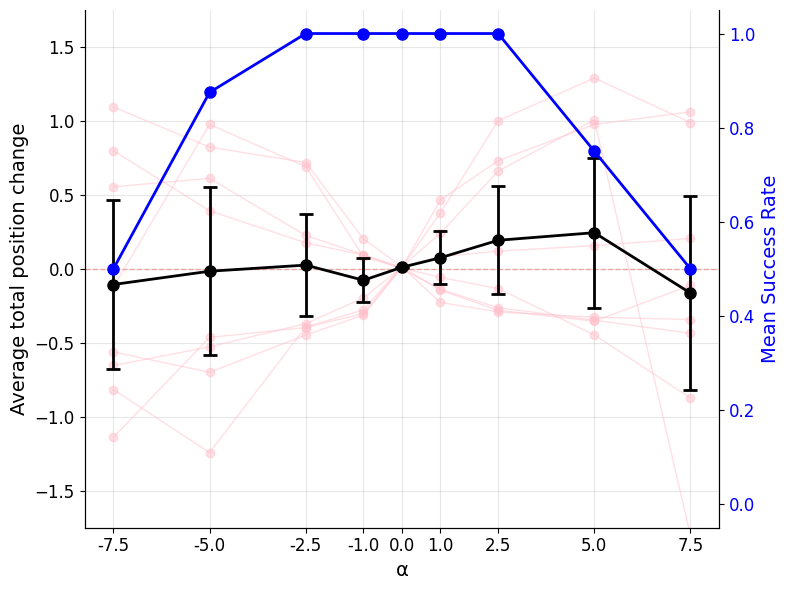

In [41]:
df_to_plot = df[df['config_direction_str'] ==
                'backprop_gradient_linear_position']

df_to_plot = df[df['config_direction_str'] == 'w_action_lasso']
df_to_plot = df[df['config_direction_str'] == 'spsa']
fig, ax1 = plt.subplots(figsize=(8, 6))

# Group by alpha
grouped = df_to_plot.groupby('config_magnitude')

# Left y-axis: total_position_change
ax1.set_xlabel('α', fontsize=14)
ax1.set_ylabel('Average total position change', fontsize=14)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.3, linewidth=1)

# Plot one line per seed
for seed in df_to_plot['config_seed'].unique():
    seed_data = df_to_plot[df_to_plot['config_seed'] == seed].sort_values(
        'config_magnitude')
    ax1.plot(seed_data['config_magnitude'],
             seed_data['total_position_change'],
             color='pink',
             marker='o',
             alpha=0.5,
             linewidth=1)

# Plot mean with error bars (95% CI)
alphas = []
means = []
ci_lower = []
ci_upper = []

for alpha, group in grouped:
    alphas.append(alpha)
    mean_val = group['total_position_change'].mean()
    means.append(mean_val)
    std_val = group['total_position_change'].std()
    n = len(group)
    ci = 1.96 * std_val / np.sqrt(n)  # 95% CI
    ci_lower.append(mean_val - ci)
    ci_upper.append(mean_val + ci)

ax1.errorbar(alphas,
             means,
             yerr=[
                 np.array(means) - np.array(ci_lower),
                 np.array(ci_upper) - np.array(means)
             ],
             fmt='o-',
             color='black',
             linewidth=2,
             markersize=8,
             capsize=5,
             capthick=2,
             label='Mean ± 95% CI')

ax1.tick_params(axis='y', labelcolor='black', labelsize=12)
ax1.tick_params(axis='x', labelsize=12)
ax1.set_xticks(alphas)
ax1.set_xticklabels([str(a) for a in alphas])
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-1.75, 1.75)

# Right y-axis: success rate
ax2 = ax1.twinx()
ax2.set_ylabel('Mean Success Rate', fontsize=14, color='blue')
ax2.set_ylim(-0.05, 1.05)
# Calculate success rate for each alpha
success_rates = []
for alpha, group in grouped:
    success_rate = group['success'].mean()
    success_rates.append(success_rate)

ax2.plot(alphas,
         success_rates,
         'o-',
         color='blue',
         linewidth=2,
         markersize=8,
         label='Success Rate')
ax2.tick_params(axis='y', labelcolor='blue', labelsize=12)
#ax2.set_ylim(0, 1.1)

# Title
#plt.title('spsa', fontsize=16)

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
#ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=12)

plt.tight_layout()
sns.despine(top=True, right=False)
plt.show()
